# 1. Variables and equations: describe an unknown and solve for it

Learn the difference between a mathematical equality and Python assignment, substitute values into an expression, solve simple linear equations, and check solutions independently. Prerequisite: [fractions, percentages, and exponents](../../../02_Mathematics_for_ML/01_fractions_percentages_and_exponents.ipynb). Our example is an invented delivery-price rule. No statistical fitting is performed: all rule coefficients are supplied rather than learned.

## 2. What problem does this solve?

A formula describes how quantities relate. Sometimes you know the input and want the output; sometimes you know the desired output and need the input that produces it. Machine learning later adds another question: which coefficients should be learned from observations? Before that, we need to distinguish the unknown input from the coefficients defining a rule.

Suppose a courier charges a fixed fee plus a charge per kilometer. Predicting a price uses substitution. Finding the distance corresponding to a known price uses equation solving. The same mathematical relationship supports both tasks, but we must identify which quantities are known in each one.

## 3. Intuition and analogy

An equation resembles a balanced scale. Both sides have the same value. Adding the same quantity to both sides preserves balance. Dividing both sides by a nonzero quantity also preserves balance. Solving means applying valid operations until the unknown stands alone.

A variable is a name for a quantity that may be unknown or may vary. It is not an instruction to multiply letters together without definitions. Choosing a descriptive name such as `distance_km` in Python helps preserve units; writing $x$ in mathematics is convenient only when its meaning is explained.

## 4. Terminology

An **expression** computes a value, such as $2x+3$. An **equation** states equality between expressions, such as $2x+3=11$. A **solution** is a value making the equality true. A **coefficient** multiplies a variable; a **constant** is fixed within the current problem. **Substitution** replaces a symbol with a specified value.

In Python, `x = 4` assigns a value to a name. `x == 4` tests equality and produces a Boolean. Python does not solve an equation merely because you write an equality test. `2*x` is multiplication; mathematical prose often omits the multiplication sign in $2x$, but Python requires it.

## 5. Mathematical foundations

Our price rule is

$$p=ad+b.$$

$p$ is price in dollars, $d$ is nonnegative distance in kilometers, $a$ is the distance charge in dollars per kilometer, and $b$ is the fixed fee in dollars. Multiplying $a$ by $d$ produces dollars, so adding $b$ is dimensionally consistent. All quantities here are scalars: one value rather than an array.

If $a\ne0$, solving for distance gives $d=(p-b)/a$. Subtract $b$ from both sides and divide both sides by $a$. If $a=0$, price is constant: a matching price allows every admissible distance, while a different price allows none. The existence of a numerical solution also does not guarantee it satisfies a domain constraint such as nonnegative distance.

## 6. Hand-calculated example

Let $a=2$ dollars per kilometer and $b=3$ dollars. A four-kilometer trip costs $2\times4+3=11$ dollars. To solve $2d+3=11$, subtract three to obtain $2d=8$, then divide by two to obtain $d=4$ kilometers. Substitute back to check: $2\times4+3=11$.

A price of one dollar would produce $d=(1-3)/2=-1$ kilometers. The algebra is correct but the solution violates our courier's nonnegative-distance domain. A modeling or application rule must enforce that domain rather than accepting every algebraic answer.

## 7. Substitution and solving from scratch

In [1]:
# Enable embedded figures in this fresh notebook kernel.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

In [2]:
charge_per_km = 2.0
fixed_fee = 3.0
distance_km = 4.0
price_dollars = charge_per_km * distance_km + fixed_fee
assert price_dollars == 11.0
known_price = 11.0
after_subtraction = known_price - fixed_fee
solved_distance = after_subtraction / charge_per_km
assert after_subtraction == 8.0 and solved_distance == 4.0
assert charge_per_km * solved_distance + fixed_fee == known_price
print('Subtract fee:', after_subtraction, 'dollars')
print('Divide by charge:', solved_distance, 'km')

Subtract fee: 8.0 dollars
Divide by charge: 4.0 km


The code performs the algebraically derived steps. It does not search for a solution or learn the coefficients. Keeping each intermediate quantity visible helps diagnose a sign error or a wrong denominator.

## 8. Output inspection and domain validation

Implement a deliberately restricted interface for positive distance charges and nonnegative fees. `math.isfinite` excludes infinities and NaN. These restrictions belong to the courier example; a general linear equation solver would allow negative coefficients and handle degenerate cases differently.

In [3]:
import math
def distance_for_price(price, charge, fee):
    for value in [price, charge, fee]:
        if isinstance(value, bool) or not isinstance(value, (int, float)) or not math.isfinite(value):
            raise ValueError('Use finite ordinary numeric values, excluding bool.')
    if charge <= 0 or fee < 0 or price < fee:
        raise ValueError('Require positive charge, nonnegative fee, and price at least fee.')
    return (price - fee) / charge

assert distance_for_price(11, 2, 3) == 4
assert distance_for_price(3, 2, 3) == 0
try:
    distance_for_price(1, 2, 3)
except ValueError as error:
    print('Domain check:', error)
else:
    raise AssertionError('Negative distance should not be accepted.')

Domain check: Require positive charge, nonnegative fee, and price at least fee.


## 9. Library comparison

NumPy can solve a system represented as a coefficient matrix and right-hand-side vector. For this one-equation example, the matrix has shape `(1,1)` containing the charge, and the vector has shape `(1,)` containing price minus fee. The solution vector has shape `(1,)`. Direct arithmetic is simpler here; matrix solving becomes useful when several unknowns interact.

In [4]:
import numpy as np
coefficient_matrix = np.array([[2.0]])
right_hand_side = np.array([11.0 - 3.0])
library_solution = np.linalg.solve(coefficient_matrix, right_hand_side)
assert coefficient_matrix.shape == (1, 1) and library_solution.shape == (1,)
np.testing.assert_allclose(library_solution, [solved_distance])
np.testing.assert_allclose(coefficient_matrix @ library_solution, right_hand_side)
print('Library solution:', library_solution[0], 'km')

Library solution: 4.0 km


The `@` operator performs matrix multiplication. In this one-by-one case it reproduces ordinary multiplication. A later linear-algebra lesson explains the general operation. A singular coefficient matrix may have no unique solution; a library cannot create uniqueness that the equation lacks.

## 10. Visualization

The rising line gives price for every nonnegative distance in the displayed range. The horizontal eleven-dollar line intersects it at four kilometers. The point at distance zero has price three dollars, showing the fixed fee. The line's rise per kilometer is two dollars.

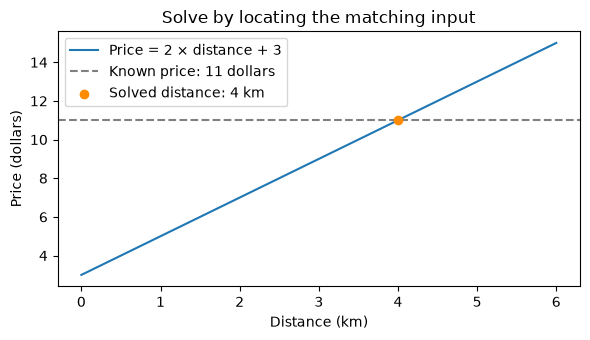

In [5]:
import matplotlib.pyplot as plt
distances = np.linspace(0, 6, 61)
prices = charge_per_km * distances + fixed_fee
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(distances, prices, label='Price = 2 × distance + 3')
ax.axhline(11, color='gray', linestyle='--', label='Known price: 11 dollars')
ax.scatter([4], [11], color='darkorange', zorder=3, label='Solved distance: 4 km')
ax.set(xlabel='Distance (km)', ylabel='Price (dollars)', title='Solve by locating the matching input')
ax.legend()
fig.tight_layout()
display(fig)
plt.close(fig)

## 11. Experiment: change coefficients separately

Keep the desired price fixed at eleven dollars. Raising the distance charge from two to four dollars per kilometer reduces the affordable distance from four to two kilometers. Raising only the fee from three to five reduces it from four to three kilometers. These are consequences of the stated rule, not estimated effects from observational data.

In [6]:
assert distance_for_price(11, 4, 3) == 2
assert distance_for_price(11, 2, 5) == 3
zero_charge_prices = [0 * distance + 3 for distance in [0, 2, 10]]
assert zero_charge_prices == [3, 3, 3]
assert 2 * 4 + 3 == 11
assert 2 * 4 + 3 != 10
print('Higher charge:', distance_for_price(11, 4, 3), 'km')
print('Higher fee:', distance_for_price(11, 2, 5), 'km')

Higher charge: 2.0 km
Higher fee: 3.0 km


## 12. Known coefficients versus learned parameters

The charge and fixed fee are supplied business-rule coefficients here. They are not learned from observations, and this lesson has no fitted model or tuning procedure. Later linear regression treats analogous coefficients as parameters to estimate from training examples. An equation describes the relation; a learning procedure explains how chosen coefficients are obtained. Do not confuse those two tasks.

## 13. Evaluation

Verify a proposed solution by substitution into the original equation, not only by repeating the rearranged formula. Check units and domain constraints. For floating-point calculations, use a tolerance for residual $r=ad+b-p$, measured in dollars. A residual near zero supports arithmetic correctness; it does not establish that the courier rule describes a real service.

In [7]:
for price in [3.0, 5.5, 11.0, 15.25]:
    distance = distance_for_price(price, 2.0, 3.0)
    residual = 2.0 * distance + 3.0 - price
    assert distance >= 0 and math.isclose(residual, 0.0, abs_tol=1e-12)
print('Substitution residuals are zero within tolerance.')

Substitution residuals are zero within tolerance.


## 14. Assumptions and limitations

The price relation is linear, the same rate applies across the full distance, and fees do not depend on traffic or package mass. There is no rounding policy or minimum billing increment. Exact business prices often need decimal monetary rules rather than unrestricted floating-point arithmetic. This example teaches algebra and domain checking, not a production billing system.

## 15. Common mistakes and debugging

Subtract the fee before dividing by the charge; `(p-b)/a` is different from `p-b/a`. Do the same valid operation to both sides when deriving a solution. Never divide by a variable expression without considering when it could be zero. Keep units consistent: inserting meters into a kilometers-based rule changes the result by a factor of a thousand.

Avoid treating assignment as a mathematical assertion. `price = 11` binds a value; it does not force other variables to satisfy an equation. Recompute an expression after changing an input. Notebook variables store results, not automatically updating spreadsheet formulas.

## 16. Alternatives and related methods

Direct algebra is best for this small equation. A graph helps explain the solution visually but is less precise than substitution. Numerical root-finding helps equations that cannot easily be rearranged, while linear-system solvers handle interacting linear unknowns. Statistical fitting estimates coefficients from noisy observations; it is a different problem from solving a known exact equation.

## 17. Exercises

- **Beginner:** Solve $3x+2=14$ and verify by substitution.
- **Beginner:** Calculate the price of a five-kilometer trip under the original rule, with units.
- **Beginner:** Explain why `x = 4` and `x == 4` do different things in Python.
- **Intermediate:** Explain the solution sets for $0x+3=3$ and $0x+3=8$.
- **Intermediate:** Derive the required charge per kilometer when price is 15 dollars, fee 3 dollars, and distance 4 kilometers.
- **Challenge:** Write a general finite-scalar equation classifier for $ax+b=c$ returning a unique solution, all real values, or no solution. Test positive, negative, and zero coefficients, and explain its distinction from the courier domain.

## 18. Detailed solutions

Subtract two and divide by three: $x=4$; substitution gives fourteen. Five kilometers costs $2\times5+3=13$ dollars. Assignment binds a value while equality tests a statement. When the coefficient is zero, the first equation is true for every real $x$ and the second for none. Charge is $(15-3)/4=3$ dollars per kilometer.

The challenge allows negative solutions and coefficients because it describes real scalar algebra rather than the courier's restricted input domain. Exact zero comparisons here classify explicitly supplied coefficients; nearly zero floating-point coefficients can require numerical conditioning analysis in more advanced work.

In [8]:
def classify_equation(a, b, c):
    if any(isinstance(v, bool) or not isinstance(v, (int, float)) or not math.isfinite(v) for v in [a, b, c]):
        raise ValueError('Use finite ordinary numeric coefficients.')
    if a == 0:
        return ('all real values', None) if b == c else ('no solution', None)
    return 'unique', (c - b) / a

assert 3 * 4 + 2 == 14 and 2 * 5 + 3 == 13
assert (15 - 3) / 4 == 3
assert classify_equation(3, 2, 14) == ('unique', 4.0)
assert classify_equation(-2, 3, 11) == ('unique', -4.0)
assert classify_equation(0, 3, 3) == ('all real values', None)
assert classify_equation(0, 3, 8) == ('no solution', None)
print('Equation classifications and substitution exercises passed.')

Equation classifications and substitution exercises passed.


## 19. Knowledge check

**What makes a value a solution?** Substituting it makes the original equality true.

**Why subtract the same fee from both sides?** Equal quantities remain equal after the same operation.

**What units does the charge have?** Dollars per kilometer, so charge times distance is dollars.

**Can a valid algebraic solution be inadmissible?** Yes. Negative distance violates the courier domain.

**Are coefficients learned in this lesson?** No. They are supplied rules.

## 20. Interview preparation

**How do solving and fitting differ?** Solving finds unknowns under a known relation; fitting estimates a relation's parameters from observations.

**How would you verify a solver?** Substitute its answer into the original equation and inspect residual, units, and domain.

**Why handle zero coefficients explicitly?** Division is invalid and the equation may have all values or no solution rather than a unique one.

**What does numerical conditioning concern?** How sensitive a computed answer is to small input changes; tiny divisors can amplify changes.

**Why use descriptive names in code?** Names such as distance_km preserve semantic and unit information that bare symbols can hide.

## 21. Summary and next steps

Define known quantities and unknowns, preserve equality with valid operations, and verify by substitution. Continue to the existing [functions and derivatives preview](../../../02_Mathematics_for_ML/03_functions_and_derivatives.ipynb), then [functions and graphs](../../../02_Mathematics_for_ML/04_functions_and_graphs.ipynb) for a slower introduction to input-output relationships.